# Анализ мобильного приложения

### Цель анализа
Провести исследование данных по продажам и подготовить отчет с информацией для Product Manager.

### Задачи
1. Провести анализ retention и написать функцию для его расчета.
2. Провести анализ результатов A/B тестирования. Определить лучшее предложение и метрики для принятия решения.
3. Предложить метрики для оценки результатов последнего прошедшего тематического события в игре.

In [197]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlencode
import requests
from scipy.stats import zscore

%matplotlib inline

## Задача 1

**Провести анализ retention и написать функцию для его расчета.**

План:
1. Загрузка и проверка данных
2. Расчет retention
    - Объединить таблицы
    - Определить когорты
    - Добавить признак когорт для каждой продажи
    - Добавить разницу между каждой продажей и первой продажей клиента
    - Добавить расчет ретеншн
    - Сделать pivot и добавить стилизацию
3. Написание функции

### 1. Загрузка и проверка данных

In [134]:
# Объявляем функцию для загрузки файлов с Яндекс Диска
def yadisk_url(url):
    base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
    final_url = base_url + urlencode(dict(public_key=url))
    response = requests.get(final_url)
    download_url = response.json()['href']
    return download_url

In [135]:
# Готовим ссылки для анализируемых файлов
reg_url = yadisk_url('https://disk.yandex.ru/d/Hhs5TfnJLAssgg')
auth_url = yadisk_url('https://disk.yandex.ru/d/iqE2rAOEVnnr4A')

In [136]:
# Читаем все данные из файлов и сохраняем их в data frame
reg_data = pd.read_csv(reg_url, sep=';')
auth_data = pd.read_csv(auth_url, sep=';')


In [137]:
# Проверим DF с данными по регистрации
reg_data.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [138]:
# Преобразуем колонку с датой
reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')

In [139]:
# Проверим преобразование дат в DF с данными по регистрации
reg_data.head()

,reg_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,2000-01-13 22:27:27,3
3,2000-05-28 14:19:01,4
4,2000-09-16 11:21:53,5


In [140]:
# Посмотрим инфорамацию по df
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   reg_ts  1000000 non-null  datetime64[ns]
 1   uid     1000000 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 15.3 MB


In [141]:
# Посмотрим описательную статистику по данным
reg_data.describe()

,reg_ts,uid
count,1000000,1.000000e+06
mean,2019-01-24 12:12:34.523666688,5.552354e+05
min,1998-11-18 09:43:43,1.000000e+00
25%,2018-06-03 13:55:11.500000,2.776438e+05
50%,2019-07-30 02:35:25,5.550455e+05
75%,2020-04-01 16:28:40.500000,8.329712e+05
max,2020-09-23 15:17:24,1.110622e+06
std,NaN,3.206011e+05


In [142]:
# Посчитаем уникальные значения
reg_data.nunique()

reg_ts    1000000
uid       1000000
dtype: int64

Данные `reg_data`
- `reg_ts` - дата регистрации, мы преобразовали данные в `datetime64[ns]`
- `uid` - уникальный идентификатор пользователя в формате `int64`
- общее количество уникальных записей 1000000 -> это общее количество зарегистированных пользователей
- пустых значений в df нет
- первая дата регистрации - 1998-11-18 09:43:43
- последняя дата регистрации - 2020-09-23 15:17:24
- больше 50% регистраций было осуществлено за последний год

In [143]:
# Проверим результат загрузки данных
auth_data.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [144]:
# Преобразуем колонку с датой
auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')

In [145]:
# Проверим результат преобразования данных
auth_data.head()

,auth_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,1999-07-25 16:46:46,2
3,1999-07-31 03:50:15,2
4,1999-08-05 17:49:39,2


In [146]:
# Посмотрим инфорамцию по df
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype         
---  ------   -----         
 0   auth_ts  datetime64[ns]
 1   uid      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 146.5 MB


In [147]:
# Поскольку df очень объемный, то метод info не может проверить пустые значени
# Проверим отдельно пустые значения
auth_data.isnull().sum()

auth_ts    0
uid        0
dtype: int64

In [148]:
# Посмотрим описательную статистику по данным
auth_data.describe()

,auth_ts,uid
count,9601013,9.601013e+06
mean,2019-01-29 16:12:06.254851584,3.347198e+05
min,1998-11-18 09:43:43,1.000000e+00
25%,2018-06-07 12:40:47,9.599700e+04
50%,2019-07-31 12:43:16,2.579210e+05
75%,2020-04-02 10:25:21,5.190250e+05
max,2020-09-23 15:17:24,1.110622e+06
std,NaN,2.832669e+05


In [149]:
# Посчитаем уникальные значения
auth_data.nunique()

auth_ts    9180915
uid        1000000
dtype: int64

Данные `auth_data`
- `auth_ts` - дата авторизаций, мы преобразовали данные в `datetime64[ns]`
- `uid` - уникальный идентификатор пользователя в формате `int64`
- общее количество авторизаций 9180915, при этом общее количество уникальных пользователей идентично количеству в `reg_data`
- пустых значений в df нет
- первая дата авторизации - 1998-11-18 09:43:43
- последняя дата авторизации - 2020-09-23 15:17:24
- больше 50% регистраций было осуществлено за последний год

### 2. Расчет retention

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока).

In [150]:
# Объединим DF, использовать будем left по таблице с регистрациями, т.к. это точка первого касания с приложением 
app_data = pd.merge(reg_data, auth_data, how='left', on='uid')
app_data.head()

,reg_ts,uid,auth_ts
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43
1,1999-07-22 22:38:09,2,1999-07-22 22:38:09
2,1999-07-22 22:38:09,2,1999-07-25 16:46:46
3,1999-07-22 22:38:09,2,1999-07-31 03:50:15
4,1999-07-22 22:38:09,2,1999-08-05 17:49:39


In [151]:
# Посмотрим размер df
app_data.shape

(9601013, 3)

Объединение таблиц прошло успешно. Общее количество строк равно 9601013, что соответствует общему количество авторизаций в таблице `auth_data`

In [152]:
# Добавим колонку в которой время переведем в формат периода (дня) для последующей группировки 
app_data['reg_date'] = app_data['reg_ts'].dt.to_period('D')
app_data['auth_date'] = app_data['auth_ts'].dt.to_period('D')

In [153]:
# Проверим добавление новых колонок
app_data.head()

,reg_ts,uid,auth_ts,reg_date,auth_date
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43,1998-11-18,1998-11-18
1,1999-07-22 22:38:09,2,1999-07-22 22:38:09,1999-07-22,1999-07-22
2,1999-07-22 22:38:09,2,1999-07-25 16:46:46,1999-07-22,1999-07-25
3,1999-07-22 22:38:09,2,1999-07-31 03:50:15,1999-07-22,1999-07-31
4,1999-07-22 22:38:09,2,1999-08-05 17:49:39,1999-07-22,1999-08-05


In [154]:
# Дата регистрации будет выступать источником данных для образования когорт
# Введем новые переменные
start_date = pd.Period('2020-05-01', freq='D')
end_date = pd.Period('2020-05-10', freq='D')

In [155]:
# Отфильтруем значения в df согласно переменных по датам
app_data = app_data[(app_data['reg_date'] >= start_date) & (app_data['auth_date'] <= end_date)]
app_data.head()

,reg_ts,uid,auth_ts,reg_date,auth_date
9009122,2020-05-01 00:01:00,874066,2020-05-01 00:01:00,2020-05-01,2020-05-01
9009123,2020-05-01 00:02:07,874067,2020-05-01 00:02:07,2020-05-01,2020-05-01
9009124,2020-05-01 00:03:14,874068,2020-05-01 00:03:14,2020-05-01,2020-05-01
9009125,2020-05-01 00:03:14,874068,2020-05-03 15:44:00,2020-05-01,2020-05-03
9009126,2020-05-01 00:03:14,874068,2020-05-09 06:30:24,2020-05-01,2020-05-09


In [156]:
# Рассчитываем разницу в днях между регистрацией и аутентификацией
app_data['visit_dif'] = (app_data['auth_date'] - app_data['reg_date']).apply(lambda x: x.n)
app_data.head()

,reg_ts,uid,auth_ts,reg_date,auth_date,visit_dif
9009122,2020-05-01 00:01:00,874066,2020-05-01 00:01:00,2020-05-01,2020-05-01,0
9009123,2020-05-01 00:02:07,874067,2020-05-01 00:02:07,2020-05-01,2020-05-01,0
9009124,2020-05-01 00:03:14,874068,2020-05-01 00:03:14,2020-05-01,2020-05-01,0
9009125,2020-05-01 00:03:14,874068,2020-05-03 15:44:00,2020-05-01,2020-05-03,2
9009126,2020-05-01 00:03:14,874068,2020-05-09 06:30:24,2020-05-01,2020-05-09,8


In [157]:
# Группируем данные по когортам и индексам (разнице между датами)
app_cohort = app_data \
    .groupby(['reg_date', 'visit_dif']) \
    .agg({'uid': 'count'}) \
    .rename(columns={'uid': 'users'}) \
    .sort_values(by='reg_date')

In [158]:
# Расчитываем ретеншн и записываем в новую колонку
app_cohort['retention'] = app_cohort['users'] / app_cohort.groupby(['reg_date'])['users'].transform('max')
app_cohort.head()

users  retention
reg_date   visit_dif                  
2020-05-01 0           1295   1.000000
           1             20   0.015444
           2             51   0.039382
           3             59   0.045560
           4             64   0.049421

In [159]:
# Для наглядности добавим размер каждой когорты
app_cohort['size'] = app_cohort.groupby(['reg_date'])['users'].transform('max')
app_cohort.head()

users  retention  size
reg_date   visit_dif                        
2020-05-01 0           1295   1.000000  1295
           1             20   0.015444  1295
           2             51   0.039382  1295
           3             59   0.045560  1295
           4             64   0.049421  1295

In [160]:
# Создаем pivot таблицу для полученного DF
app_cohort_pivot = app_cohort.pivot_table(index=['reg_date', 'size'], columns='visit_dif', values='retention')
app_cohort_pivot = app_cohort_pivot.loc[:, app_cohort_pivot.columns != 0]
# Применяем стили для более комфортной работы с таблицей
styled_pivot = (app_cohort_pivot
                .style
                .set_caption('Ретеншен пользователей по дням')
                .background_gradient(cmap='plasma', axis=0)
                .highlight_null('white')
                .format("{:.2%}", na_rep="")
                .set_table_styles([
                    {'selector': 'th', 'props': [('min-width', '50px')]},
                    {'selector': 'tr:hover', 'props': [('background-color', '#ffff99')]},
                ]))
styled_pivot

,visit_dif,1,2,3,4,5,6,7,8,9
reg_date,size,,,,,,,,,
2020-05-01,1295,1.54%,3.94%,4.56%,4.94%,6.02%,7.57%,6.02%,4.63%,4.63%
2020-05-02,1297,1.54%,4.47%,3.70%,5.55%,6.32%,6.25%,5.55%,5.32%,
2020-05-03,1300,1.46%,4.85%,4.23%,5.54%,5.23%,7.08%,6.62%,,
2020-05-04,1301,2.46%,3.61%,4.77%,5.92%,6.69%,7.46%,,,
2020-05-05,1304,0.92%,4.37%,4.06%,4.06%,5.98%,,,,
2020-05-06,1306,2.37%,4.29%,4.98%,4.29%,,,,,
2020-05-07,1308,2.22%,4.66%,4.59%,,,,,,
2020-05-08,1310,1.76%,4.27%,,,,,,,
2020-05-09,1313,2.51%,,,,,,,,


### 3. Реализация функции

In [161]:
def retention(registration_data, authentication_data, start_date, end_date, max_days=None, normalize_axis='columns'):
    """
    Возвращает сводную таблицу (pivot table) с retention за период.

    Параметры:
        registration_data (DataFrame): данные о регистрации пользователей.  
            Ожидаемые колонки:   
                - uid (str): уникальный идентификатор пользователя.
                - reg_ts (int): время регистрации в формате Unix timestamp.
        
        authentication_data (DataFrame): данные о аутентификации пользователей.
            Ожидаемые колонки:
                - uid (str): уникальный идентификатор пользователя.
                - auth_ts (int): время аутентификации в формате Unix timestamp.
        start_date (str): начальная дата периода в формате 'YYYY-MM-DD'.
        end_date (str): конечная дата периода в формате 'YYYY-MM-DD'.
        max_days (int, optional): максимальное количество дней для расчета retention. По умолчанию None.
        normalize_axis (str): ось для нормализации цвета:
            - 'columns' для нормализации по строкам. По умолчанию 'columns'.
            - 'index' для нормализации по столбцам

    Возвращаемое значение:
        Styler: стилизованная сводная таблица с retention за указанный период.
    """
    # Преобразуем время регистрации из Unix timestamp в datetime
    registration_data['reg_ts'] = pd.to_datetime(registration_data['reg_ts'], unit='s')
    
    # Преобразуем время аутентификации из Unix timestamp в datetime
    authentication_data['auth_ts'] = pd.to_datetime(authentication_data['auth_ts'], unit='s')
    
    # Объединяем данные о регистрации и аутентификации по user id (uid)
    app_data = pd.merge(registration_data, authentication_data, how='left', on='uid')
    
    # Преобразуем datetime регистрации в период (день)
    app_data['reg_date'] = app_data['reg_ts'].dt.to_period('D')
    
    # Преобразуем datetime аутентификации в период (день)
    app_data['auth_date'] = app_data['auth_ts'].dt.to_period('D')
    
    # Фильтруем по заданному временному промежутку
    start = pd.Period(start_date, freq='D')
    end = pd.Period(end_date, freq='D')
    app_data = app_data[(app_data['reg_date'] >= start) & (app_data['auth_date'] <= end)]

    # Рассчитываем разницу в днях между регистрацией и аутентификацией
    app_data['visit_dif'] = (app_data['auth_date'] - app_data['reg_date']).apply(lambda x: x.n)

    # Фильтруем по границе дней для расчета retention
    if max_days is not None:
        app_data = app_data[app_data['visit_dif'] <= max_days]

    # Группируем данные по когортам и индексам (разнице между датами)
    app_cohort = app_data \
        .groupby(['reg_date', 'visit_dif']) \
        .agg({'uid': 'count'}) \
        .rename(columns={'uid': 'users'}) \
        .sort_values(by='reg_date')
    
    # Расчитываем retention и записываем в новую колонку
    app_cohort['retention'] = app_cohort['users'] / app_cohort.groupby(['reg_date'])['users'].transform('max')

    # Для наглядности добавим размер каждой когорты
    app_cohort['size'] = app_cohort.groupby(['reg_date'])['users'].transform('max')

    # Создаем pivot таблицу для полученного DF
    app_cohort_pivot = app_cohort.pivot_table(index=['reg_date', 'size'], columns='visit_dif', values='retention')
    
    # Уберем из результирующей таблицы колонку с днем аутентификации (retention всегда будет 100%)
    app_cohort_pivot = app_cohort_pivot.loc[:, app_cohort_pivot.columns != 0]
    # Удаляем полностью пустые строки
    app_cohort_pivot = app_cohort_pivot.dropna(how='all', axis=0)
    
    # Применяем стили для более комфортной работы с таблицей
    styled_pivot = (app_cohort_pivot
                    .style
                    .set_caption('Ретеншен пользователей по дням')
                    .background_gradient(cmap='plasma', axis=normalize_axis)
                    .highlight_null('white')
                    .format("{:.2%}", na_rep="") 
                    .set_table_styles([
                        {'selector': 'th', 'props': [('min-width', '50px')]},
                        {'selector': 'tr:hover', 'props': [('background-color', '#ffff99')]},
                    ]))
    return styled_pivot

In [162]:
# Запустим тест функции
retention(reg_data, auth_data, '2020-06-01', '2020-06-15', 7, 'columns')

,visit_dif,1,2,3,4,5,6,7
reg_date,size,,,,,,,
2020-06-01,1363,1.69%,5.21%,4.18%,4.48%,5.80%,7.63%,5.58%
2020-06-02,1365,1.76%,3.30%,4.84%,5.86%,5.71%,7.11%,5.64%
2020-06-03,1368,1.97%,3.58%,4.82%,3.58%,5.63%,7.02%,6.21%
2020-06-04,1369,1.83%,3.94%,4.16%,4.97%,6.43%,5.99%,5.48%
2020-06-05,1372,1.97%,3.35%,4.15%,4.52%,5.47%,6.85%,4.37%
2020-06-06,1375,2.04%,3.64%,4.87%,4.80%,5.96%,7.27%,5.53%
2020-06-07,1376,1.38%,4.36%,5.23%,4.80%,5.89%,5.45%,6.98%
2020-06-08,1379,1.74%,2.76%,4.50%,5.73%,5.95%,6.89%,4.50%
2020-06-09,1381,1.88%,3.84%,4.13%,5.94%,5.29%,6.66%,


#### Результаты

- Данные были успешно сохранены на Яндекс Диске, для чего была разработана функция взаимодействия с API Яндекс Диска.  
- Проведен предварительный анализ имеющихся данных.  
- Выполнен расчет коэффициента удержания пользователей (retention).  
- Результаты расчетов интегрированы в функцию retention, которая включает гибкие настройки:
	- Определение периода расчета.  
	- Указание разницы в днях с момента регистрации (дни расчета).  
	- Выбор типа цветовой визуализации для наглядного представления данных.  

**В ходе анализа выявлены следующие тенденции:**
1.	Наблюдается довольно низкий коэффициент удержания на первый день после регистрации.
2.	Самый высокий средний коэффициент удержания приходится на 6-й день, что может указывать на наличие внутренних механизмов возврата пользователей (например, push-уведомления, нотификации, акции, подарки и т.д.), активно действующих на этом этапе.

## Задача 2
**Провести анализ результатов A/B тестирования. Определить лучшее предложение и метрики для принятия решения.**

**Контекст**
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

**Вопросы**  
Какой набор предложений можно считать лучшим?  
Какие метрики стоит проанализировать для принятия правильного решения и как?


План:
1. Загрузка и проверка данных логов
2. Сверить соответствие вводной информации и данных логов
3. Работа с метриками
4. Сформулировать заключение по наборам акционных предложений

### 1. Загрузка и проверка данных

In [163]:
# Готовим ссылку для файла с данными
ab_data_url = yadisk_url('https://disk.yandex.ru/d/SOkIsD5A8xlI7Q')

In [164]:
# Читаем данные из файла и сохраняем их в data frame
ab_data = pd.read_csv(ab_data_url, sep=';')
ab_data.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [165]:
# Посмотрим инфорамацию по df
ab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


In [166]:
# Посчитаем уникальные значения
ab_data.nunique()

user_id      404770
revenue        1477
testgroup         2
dtype: int64

In [167]:
# Посмотрим описательную статистику по данным
ab_data.describe()

,user_id,revenue
count,404770.000000,404770.000000
mean,202385.500000,26.083435
std,116847.178567,681.652928
min,1.000000,0.000000
25%,101193.250000,0.000000
50%,202385.500000,0.000000
75%,303577.750000,0.000000
max,404770.000000,37433.000000


Можем наблюдать выраженную неравномерность распределения выручки. Что скорее всего вызванно большим количеством пользователей с выручкой равной нулю.
Для наглядности построим график распределения.

Text(0.5, 1.0, 'Распределение выручки по группам')

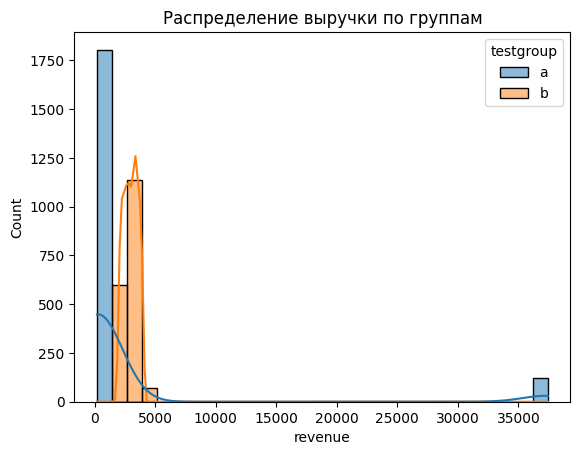

In [168]:
# Построение гистограмм для распределения выручки по группам
sns.histplot(data=ab_data[ab_data.revenue > 0], x='revenue', hue='testgroup', kde=True, bins=30)
plt.title('Распределение выручки по группам')

По группе А видим выброс в правой части графика, который сильно искажает описательную статистику нашего набора данных.

Посмотрим на выручку по группам более детально.

In [169]:
# Сделаем отдельные df для каждой группы
a_data = ab_data[ab_data.testgroup == 'a']
b_data = ab_data[ab_data.testgroup == 'b']

In [170]:
# Посмотрим описательную статистику по данным
a_data.describe()

,user_id,revenue
count,202103.000000,202103.000000
mean,202555.909843,25.413720
std,116802.329266,920.768137
min,2.000000,0.000000
25%,101502.500000,0.000000
50%,202988.000000,0.000000
75%,303559.000000,0.000000
max,404769.000000,37433.000000


In [171]:
# Посмотрим описательную статистику по данным с фильтром по выручке больше нуля
a_data[a_data['revenue'] > 0].describe()

,user_id,revenue
count,1928.000000,1928.000000
mean,200152.677905,2663.998444
std,116596.504905,9049.039763
min,73.000000,200.000000
25%,99323.000000,257.000000
50%,199854.500000,311.000000
75%,299664.250000,361.000000
max,404768.000000,37433.000000


In [172]:
# Посмотрим описательную статистику по данным с фильтром по выручке больше нуля, но меньше 30 000
a_data[(a_data.revenue > 0) & (a_data.revenue < 30000)].describe()

,user_id,revenue
count,1805.000000,1805.000000
mean,199923.686981,302.458172
std,116615.234772,57.914246
min,73.000000,200.000000
25%,98963.000000,254.000000
50%,199268.000000,305.000000
75%,298918.000000,352.000000
max,404768.000000,400.000000


In [173]:
# Посмотрим описательную статистику по данным с фильтром по выручке больше 30000
a_data[(a_data.revenue > 30000)].describe()

,user_id,revenue
count,123.000000,123.000000
mean,203513.073171,37319.121951
std,116745.137742,25.442183
min,417.000000,37293.000000
25%,109013.500000,37301.000000
50%,204560.000000,37311.000000
75%,317108.500000,37329.000000
max,399295.000000,37433.000000


In [174]:
# Посчитаем выручку с фильтром по выручке больше 30000
a_data[(a_data.revenue < 30000)]['revenue'].sum()

np.int64(545937)

In [175]:
# Посчитаем выручку с фильтром по выручке меньше 30000
a_data[(a_data.revenue >= 30000)]['revenue'].sum()

np.int64(4590252)

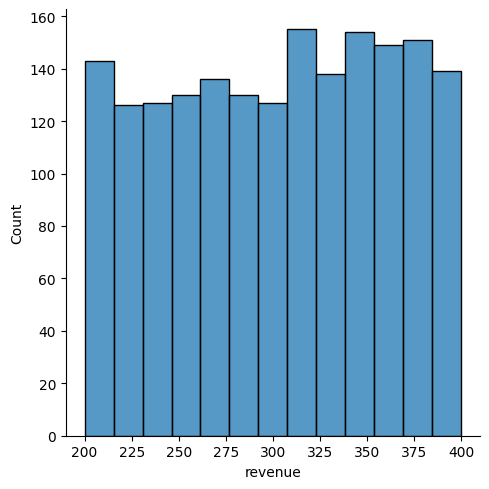

In [176]:
# Посмотрим визуализацию левой части распределения выручки по группе А
sns.displot(a_data[(a_data.revenue > 0) & (a_data.revenue < 30000)], x='revenue')

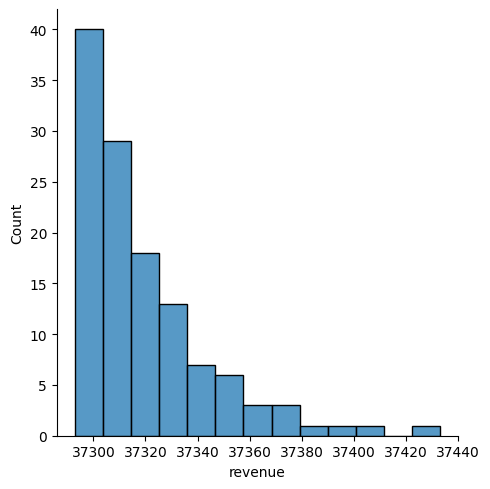

In [177]:
# Посмотрим визуализацию правой части распределения выручки по группе А
sns.displot(a_data[a_data.revenue > 30000], x='revenue')

In [178]:
# Посмотрим описательную статистику по данным
b_data[b_data['revenue'] > 0].describe()

,user_id,revenue
count,1805.000000,1805.000000
mean,205834.548476,3003.658172
std,116400.045485,572.619709
min,161.000000,2000.000000
25%,106815.000000,2513.000000
50%,206651.000000,3022.000000
75%,304907.000000,3478.000000
max,404526.000000,4000.000000


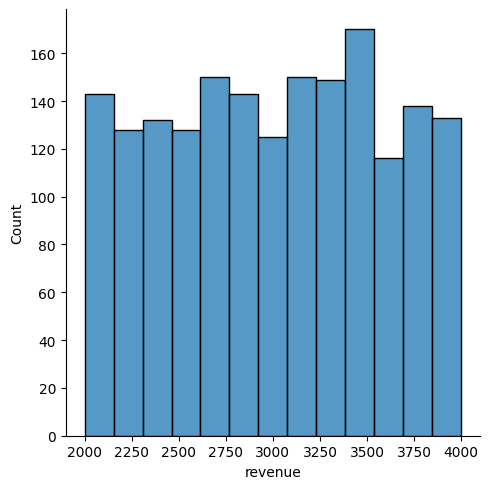

In [179]:
# Посмотрим визуализацию распределения выручки по группе B
sns.displot(b_data[b_data.revenue > 0], x='revenue')

In [180]:
# Фильтрация данных без выбросов
filtered_a_data = a_data[a_data['revenue'] <= 30000]
filtered_a_data.head()

,user_id,revenue,testgroup
1,2,0,a
2,3,0,a
9,10,0,a
10,11,0,a
11,12,0,a


In [181]:
# Посмотрим описательную статистику по отфильтрованным данным
filtered_a_data.describe()

,user_id,revenue
count,201980.000000,201980.000000
mean,202555.326958,2.702926
std,116802.650558,28.985815
min,2.000000,0.000000
25%,101494.750000,0.000000
50%,202985.500000,0.000000
75%,303550.500000,0.000000
max,404769.000000,400.000000


Text(0.5, 1.0, 'Распределение выручки по группам')

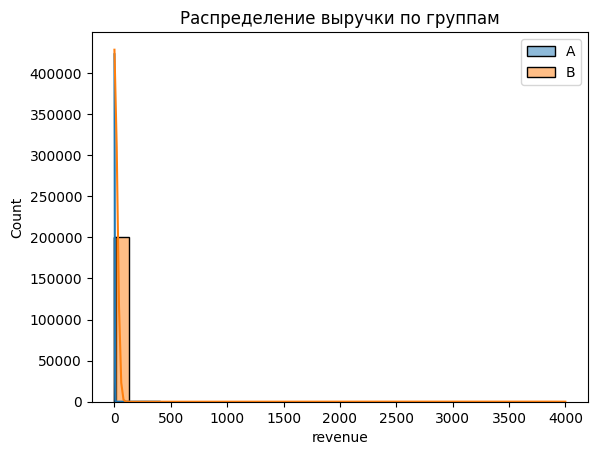

In [182]:
sns.histplot(filtered_a_data['revenue'], label='A', kde=True, bins=30)
sns.histplot(b_data['revenue'], label='B', kde=True, bins=30)

plt.legend()
plt.title('Распределение выручки по группам')

Text(0.5, 1.0, 'Распределение выручки по группам для платящих пользователей')

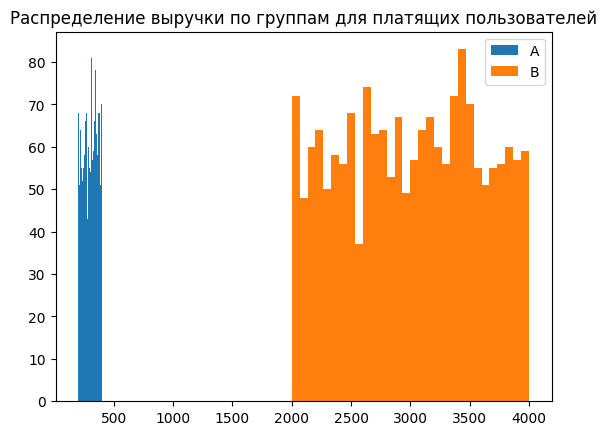

In [183]:
plt.hist(filtered_a_data[filtered_a_data.revenue > 0]['revenue'], label='A', bins=30)
plt.hist(b_data[b_data.revenue > 0]['revenue'], label='B', bins=30)

plt.legend()
plt.title('Распределение выручки по группам для платящих пользователей')

#### Результаты по данным
Данные `ab_data`
- состоят из трех колонок:
    - `user_id` - уникальный идентификатор пользователя
        - данные в формате `int64`
        - количество уникальных значений `404770`
        - пропусков в колонке нет
    - `revenue` - выручка с пользователя
        - данные в формате `int64`
        - количество значений `404770`
        - пропусков в колонке нет
    - `testgroup` - признак группы
        - данные в формате `object`
        - количество уникальных значений `404770`
        - пропусков в колонке нет
- данные по группам:
    - `testgroup A`
        - общее количество пользователей `202103` из них `1928` платящих
        - есть значительный выброс по выручке. На `123` пользователя группы приходится выручки в `8,5` раз больше чем на оставшихся `1805`. Этот выброс искажает все расчетные данные и не позволит делать адекватный прогноз.
        - в левой части распределения по выручке значения  достаточно равномерно распределены в диапазоне от `200` до `400` на пользователя
        - в правой части распределение крайне ассиметричное, значения выручки в диапазоне от `37293` до `37433` на пользователя
    - `testgroup B`
        - общее количество пользователей `202667` из них `1805` платящих
        - значения выручки достаточно равномерно распределены в диапазоне от `2000` до `4000` на пользователя

Данные достаточно чистые и готовые для дальнойшего анализа. Только прежде нужно уточнение информации по выбросу, т.к. эти значения искажают реальную картину, что отразится на дальнейшем ходе анализа.
Мы можем предполагать различные кейсы, но с точки зрения бизнеса средний чек у одной группы пользователей различающийся в 100 раз выглядит подозрительно.

### 2. Проверка соответствия вводной информации и данных логов

У нас имеется 3 утверждения, которые мы проверим:
- Количество пользователей в контрольной группе равно 202103, в тестовой 202667;
- Количество платящих пользователей в контрольной группе 1928, а в тестовой 1805;
- ARPU в тестовой группе выше на 5%, чем в контрольной.

In [184]:
# Посчитаем общее количество пользователей в группах
ab_data.groupby('testgroup').agg({'user_id': 'count'})

,user_id
testgroup,
a,202103
b,202667


In [185]:
# Создадим новую колонку в которой проставим признак платящего клиента
ab_data['has_paid'] = np.where(ab_data['revenue'] > 0, 1, 0)
ab_data.head()

,user_id,revenue,testgroup,has_paid
0,1,0,b,0
1,2,0,a,0
2,3,0,a,0
3,4,0,b,0
4,5,0,b,0


In [186]:
# Посчитаем количество платящих клиентов по группам
ab_data.groupby('testgroup').agg({'has_paid': 'sum'})

,has_paid
testgroup,
a,1928
b,1805


In [187]:
# Посчитаем ARPU 
arpu_group = ab_data \
    .groupby('testgroup') \
    .agg(ARPU=('revenue', 'mean'))

In [188]:
# Определим разницу ARPU между двумя группами
((arpu_group.ARPU['b'] / arpu_group.ARPU['a'] - 1) * 100).round(2)

np.float64(5.26)

**Результат**
Мы проверили все утверждения и они все подтвердились
- Количество пользователей в контрольной группе равно `202103`, в тестовой `202667`;
- Количество платящих пользователей в контрольной группе `1928`, а в тестовой `1805`;
- ARPU в тестовой группе выше на `5,26%`, чем в контрольной, тут в условии значение округлено до целого.

Исходя из этих результатов мы можем заключить, что группа `a` - контрольная, а `b` - тестовая.

### 3. Работа с метриками
#### Определение целевой метрики

Метрики роста:
- Paying users - количество пользователей, совершивших хотя бы одну покупку. Эта метрика отражает успех стратегии привлечения и конверсии пользователей в платящих клиентов. 
- Total revenue - общая сумма выручки, полученной от всех пользователей. Эта метрика показывает общий объем дохода, который приносит бизнес.

Метрики продукта:
- ARPU (Average Revenue Per User) - средний доход на одного пользователя, включая как платящих пользователей, так и неплатящих пользователей. Эта метрика помогает оценить общую эффективность монетизации продукта на уровне всех пользователей.
- ARPPU (Average Revenue Per Paying User) - средний доход на одного платящего пользователя. Эта метрика показывает, сколько в среднем платящий пользователь тратит на продукт, и является важной для понимания поведения платящих пользователей.
- Paying share - доля платящих пользователей среди всех пользователей. Эта метрика отражает конверсию пользователей в платящих и помогает понять, насколько продукт мотивирует пользователей к покупке.

Фокусная метрика **ARPU**, поскольку она является продуктовой метрикой, которая позволяет оценить, какое количество выручки в среднем может генерировать продукт на входном трафике пользователей. ARPU учитывает всех пользователей, включая тех, кто не совершает покупок, и таким образом дает представление о средней доходности на одного пользователя, что важно для оценки общего успеха продукта и его монетизации.


Перед тем как перейти к анализу метрик, важно оценить, насколько корректными являются значения в правой части распределения выручки для группы A. Эти значения могут существенно искажать итоговые результаты, поэтому необходимо проверить, являются ли они выбросами.

Для этого можно рассмотреть следующие подходы:
- Уточнение данных с бизнесом
- Проведение дополнительного анализа данных для выявления возможных выбросов

Так как у нас нет возможности получить обратную связь от бизнеса, мы сосредоточимся на дополнительном анализе выбросов. На первом этапе мы визуально определили границу, за которой предположительно находятся выбросы, и выявили 123 таких значения.

Для дальнейшего анализа мы будем использовать Z-преобразование, которое позволит более точно идентифицировать выбросы.

In [198]:
# Добавим столбец с расчитанными Z значениями
a_data.loc[:, 'zscore'] = zscore(a_data['revenue'])

# Установим порог значений 
z_threshold = 3

# Определим выбросы, добавим столбец с признаком
a_data.loc[:, 'is_outlier_zscore'] = a_data['zscore'].abs() > z_threshold


In [199]:
# Рассмотрим описательную статистику по полученным значениям
a_data.loc[a_data['is_outlier_zscore'], 'revenue'].describe()

count      123.000000
mean     37319.121951
std         25.442183
min      37293.000000
25%      37301.000000
50%      37311.000000
75%      37329.000000
max      37433.000000
Name: revenue, dtype: float64

Наше предположение, сделанное на первом этапе анализа, подтвердилось и мы можем утверждать, что 123 значения действительно являются выбросами.

#### Фильтруем выбросы в группе А и расчитаем метрики

In [191]:
# Подготовим общую таблицу
# Добавим левую часть распределения по выручки группы А и все данные по группе B
ab_data_filtered = pd.merge(b_data, filtered_a_data, how='outer')
ab_data_filtered.head()

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [192]:
# Создадим таблицу с метриками
metrics_filtered = ab_data_filtered \
    .groupby('testgroup') \
    .agg(
        total_users=('user_id', 'count'),
        paid_users=('revenue', lambda x: (x > 0).sum()),
        total_revenue=('revenue', 'sum'),
        ARPU=('revenue', 'mean')
    ) \
    .round(2)

In [193]:
# Расчитаем ARPPU и добавим в таблицу с метриками
metrics_filtered['ARPPU'] = round(metrics_filtered.total_revenue / metrics_filtered.paid_users, 2)

In [194]:
# Расчитаем долю платящих пользователей и добавим в таблицу с метриками
metrics_filtered['paying_share'] = round(metrics_filtered.paid_users / metrics_filtered.total_users * 100, 2)

In [195]:
# Выведем все полученные метрики
metrics_filtered

,total_users,paid_users,total_revenue,ARPU,ARPPU,paying_share
testgroup,,,,,,
a,201980,1805,545937,2.70,302.46,0.89
b,202667,1805,5421603,26.75,3003.66,0.89


In [196]:
# Рассчитаем разницу в целевой метрике между группами
(metrics_filtered['ARPU']['b'] / metrics_filtered['ARPU']['a'] - 1) * 100

np.float64(890.7407407407406)

**Результат**

При одинаковом количестве платящих пользователей и их доли, мы наблюдаем значительные различия между группами B и A.
Разница примерно в 10 раз в группе B относительно группы A проявляется в следующих ключевых метриках:
- в целевой метрике ARPU `26.75` к `2.7`
- в общем объеме выручки `5 421 603` к `545 937`
- в ARPPU `3003.66` к `302.46`

Эти различия настолько значительны, что проведение статистических тестов для подтверждения их значимости не требуется. С точки зрения бизнеса, такие крупные различия в показателях имеют очевидное значение, указывая на более высокую эффективность предложений в группе B по сравнению с группой A.

Таким образом, дополнительный статистический анализ не нужен, поскольку выводы уже достаточны для принятия управленческих решений.

### 4. Заключение

Мы провели анализ данных о пользователях, выручке и распределении по группам, выявив значительную неравномерность распределения выручки. Основной причиной этого явилось большое количество пользователей с нулевой выручкой, а также наличие выбросов в группе A, которые существенно искажают статистическую картину и влияют на оценку метрик. Для идентификации выбросов мы использовали метод Z-преобразования, что позволило определить и исключить значительные аномалии.

Для принятия окончательных решений я рекомендую использовать данные с исключенными выбросами, так как они более точно отражают реальное состояние и позволяют получить более объективные результаты по ключевым метрикам. На основе этого анализа можно сделать вывод, что набор предложений группы B является более привлекательным.

Результаты анализа показывают, что различие между группами B и A настолько значимо, что проведение дополнительных статистических тестов не требуется. Достаточно ограничиться относительным анализом метрик.

При анализе метрик мы определили ARPU (Average Revenue Per User) как основную метрику, так как она наиболее полно отражает эффективность монетизации. После рассмотрения метрик мы установили, что группа B значительно лучше монетизирует как всех пользователей (ARPU), так и платящих пользователей (ARPPU), несмотря на одинаковую долю платящих пользователей. Различие в ARPU между группами составляет `24.05` в абсолютном выражении или `890.74%` в процентном, что подчеркивает успешность стратегий группы B. 

Таким образом, можно заключить, что предложение группы B демонстрирует лучшую эффективность, что должно быть учтено при принятии продуктовых решений и масштабирования их на другие группы пользователей.

## Задача 3
**Предложить метрики для оценки результатов последнего прошедшего тематического события в игре.**

**Контекст**
В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. 

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад.

**Вопросы**  
С помощью каких метрик можно оценить результаты последнего прошедшего события?
Изменится ли набор метрик оценки результата при усложнении механики? Если да, то как?

Можно собирать большое количество метрик. Для начала я бы определился с основными целями проведения мероприятий. 
Поскольку если рассматривать проведение в первую очередь с точки зрения бизнеса, то любые метрики сведутся к финансовым показателям. В нашем кейсе речь идет про обсуждения определенного типа мероприятий, то скорее всего эта активность направлена на удержание игроков, повышение вовлеченности игроков и максимизацию дохода. Дополнительно стоит отметить, что 

**Определим метрики в каждой группе**

1-й приоритет: Метрики удержания/возвращаемости
- Event Retention (Удержание игроков во время события) - покажет, как мероприятие влияет на возвращаемость игроков и как игроки остаются вовлеченными на протяжении всего события
- Post-Event Retention (Удержание после завершения события) - покажет, насколько успешно событие повлияло на долгосрочную лояльность игроков.

2-й приоритет: Метрики вовлеченности и удовлетворенности
- Event Participation Rate (Участие в событии) - показывает, насколько интересным и привлекательным оказалось событие для игроков
- Event Completion Rate (Процент завершения события) - помогает оценить баланс сложности события. Слишком низкий процент завершения может указывать на чрезмерную сложность, тогда как слишком высокий — на недостаточную мотивацию к покупкам или участие.

3-й приоритет: Метрики дохода
- Total Revenue (Общая выручка) - основная финансовая метрика, которая напрямую отражает финансовую успешность события. Она показывает, сколько дохода принесло событие, и является ключевым показателем достижения бизнес-цели по максимизации дохода.
- ARPU (Average Revenue Per User) - показывает, насколько эффективно событие монетизирует каждого активного участника. Высокий ARPU указывает на то, что событие не только привлекает, но и эффективно превращает участников в доход.

Если мы хотим проверять какие-то отдельные гипотезы, то необходимо вводить дополнительные метрики. Так если мы решим усложнить механику событий, то базовые метрики оценки событий останутся без изменений, однако операциооные метрики, по которым мы сможем оптимизировать данный сценарий придется добавить. Тут как пример могут быть метрики 
- Количество повторных попыток - с учетом новой механики, количество попыток прохождения уровней может резко возрасти. Высокий уровень повторных попыток может указывать на слишком высокую сложность, что может негативно сказаться на вовлеченности
- Среднее время прохождения события - с увеличением сложности может вырасти время, затрачиваемое на прохождение события. Тут нужно будет искать баланс между большей вовлеченностью и фрустрацией игроков
- Конверсия в покупки - усложнение может стимулировать покупки внутриигровых предметов, которые помогут игрокам преодолеть трудности
- Доля отказывающихся пользователей от события в процессе (Drop-off Rate) - с увеличением сложности важно следить за тем какая доля пользователей перестает участвовать в событии и проводить анализ

Таким образом, при оценке событий важно учитывать как базовые метрики, которые будут одинаковые для всех мероприятий, что позволит нам сравнивать события между собой и понимать объективную оценку. Так и дополнительные показатели, которые помогут точно оценить влияние изменений в механике игры на поведение игроков и бизнес-результаты.
